In [1]:
import pandas as pd
import numpy as np
from pprint import pprint
from glob import glob
import os
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
def get_topk_dict(df, ks, metric):
    topk_d = {}
    for k in ks:
        topk_d[k] = (df[f"{metric}_rank"] <= k).mean().item()
    return topk_d

def get_rank_dict(df, ks, metric):
    rank_d = {}
    for k in ks:
        rank_d[k] = (df[f"{metric}_rank"] == k).mean().item()
    return rank_d

def get_all_topk_df(root_dp, models, model_to_metric, num_seeds, ks):

    model_topk_ds = []
    for model in models:
        seed_topk_ds = []
        for seed in range(num_seeds):
            fp = os.path.join(root_dp, f"{model}_s{seed}_summary.csv")
            df = pd.read_csv(fp)
            topk_d = get_topk_dict(df, ks, model_to_metric[model])
            topk_d["model"] = model
            seed_topk_ds.append(topk_d)
        model_topk_d = {k : list() for k in ks}
        for k in ks:
            for seed in range(num_seeds):
                model_topk_d[k].append(seed_topk_ds[seed][k])
            model_topk_d[f"{k}_mean"] = np.mean(model_topk_d[k])
            model_topk_d[f"{k}_std"] = np.std(model_topk_d[k])
            del model_topk_d[k]
        model_topk_d["model"] = model
        model_topk_ds.append(model_topk_d)
    model_topk_ds.append({"model":"random", **{f"{k}_mean": k/len(ks) for k in ks}, **{f"{k}_std": 0 for k in ks}})
    topk_df = pd.DataFrame(model_topk_ds)
    return topk_df

def get_all_rank_df(root_dp, models, model_to_metric, num_seeds, ks):

    model_rank_ds = []
    for model in models:
        seed_rank_ds = []
        for seed in range(num_seeds):
            fp = os.path.join(root_dp, f"{model}_s{seed}_summary.csv")
            df = pd.read_csv(fp)
            rank_d = get_rank_dict(df, ks, model_to_metric[model])
            rank_d["model"] = model
            seed_rank_ds.append(rank_d)
        model_rank_d = {k : list() for k in ks}
        for k in ks:
            for seed in range(num_seeds):
                model_rank_d[k].append(seed_rank_ds[seed][k])
            model_rank_d[f"{k}_mean"] = np.mean(model_rank_d[k])
            model_rank_d[f"{k}_std"] = np.std(model_rank_d[k])
            del model_rank_d[k]
        model_rank_d["model"] = model
        model_rank_ds.append(model_rank_d)       
    model_rank_ds.append({"model":"random", **{f"{k}_mean": 1/len(ks) for k in ks}, **{f"{k}_std": 0 for k in ks}})
    rank_df = pd.DataFrame(model_rank_ds)
    return rank_df

In [3]:
pubchem_retrieval_dp = "../data/ms2c/pubchem/benchmark"
inchikey_dp = os.path.join(pubchem_retrieval_dp, "ms2pubchem_nist20mona23v3_d4_wr00_inchikey_test_10ppm_MORGAN-R2_50")
scaffold_dp = os.path.join(pubchem_retrieval_dp, "ms2pubchem_nist20mona23v3_d4_wr00_scaffold_test_10ppm_MORGAN-R2_50")
# inchikey_df = pd.read_csv(inchikey_fp)
# scaffold_df = pd.read_csv(scaffold_fp)

In [4]:
num_seeds = 5
ks = list(range(1,51))
model_to_label = {
    "neims_long": "NEIMS",
    "massformer_long": "MassFormer",
    "iceberg_inten3_100_long": "ICEBERG",
    "fraggnn_d4_long": "FraGNNet-D4"
}
models = list(model_to_label.keys())
model_to_metric = {
    "neims_long": "cos_sim_0.01",
    "massformer_long": "cos_sim_0.01",
    "iceberg_inten3_100_long": "cos_sim_0.01",
    "fraggnn_d4_long": "cos_hun"
}

inchikey_topk_df = get_all_topk_df(inchikey_dp, models, model_to_metric, num_seeds, ks)
scaffold_topk_df = get_all_topk_df(scaffold_dp, models, model_to_metric, num_seeds, ks)
inchikey_rank_df = get_all_rank_df(inchikey_dp, models, model_to_metric, num_seeds, ks)
scaffold_rank_df = get_all_rank_df(scaffold_dp, models, model_to_metric, num_seeds, ks)

FileNotFoundError: [Errno 2] No such file or directory: '../data/ms2c/pubchem/benchmark/ms2pubchem_nist20mona23v3_d4_wr00_inchikey_test_10ppm_MORGAN-R2_50/neims_long_s0_summary.csv'

In [7]:
display(inchikey_rank_df)

,1_mean,1_std,2_mean,2_std,3_mean,3_std,4_mean,4_std,5_mean,5_std,...,46_std,47_mean,47_std,48_mean,48_std,49_mean,49_std,50_mean,50_std,model
0,0.182951,0.004409,0.123561,0.002944,0.088231,0.003686,0.064125,0.005514,0.053990,0.003202,...,0.000724,0.002321,0.000568,0.002179,0.000709,0.001468,0.000459,0.001326,0.000354,neims_long
1,0.164954,0.005827,0.130902,0.005865,0.095477,0.002925,0.070282,0.004326,0.053138,0.004001,...,0.000407,0.001468,0.000407,0.001326,0.000552,0.000710,0.000150,0.000521,0.000177,massformer_long
2,0.269713,0.003874,0.162065,0.005492,0.103860,0.002812,0.071655,0.003200,0.054937,0.002236,...,0.000232,0.000568,0.000439,0.000710,0.000212,0.000521,0.000407,0.000758,0.000660,iceberg_inten3_100_long
3,0.253895,0.003472,0.161449,0.004531,0.115416,0.005256,0.079564,0.004233,0.064457,0.003245,...,0.000276,0.000237,0.000150,0.000284,0.000232,0.000284,0.000232,0.000047,0.000095,fraggnn_d4_long
4,0.020000,0.000000,0.020000,0.000000,0.020000,0.000000,0.020000,0.000000,0.020000,0.000000,...,0.000000,0.020000,0.000000,0.020000,0.000000,0.020000,0.000000,0.020000,0.000000,random


In [8]:
k_means = [f"{k}_mean" for k in ks]
scaffold_topk_df[scaffold_topk_df["model"] == "neims_long"][k_means].values[0]

array([0.12738701, 0.22298713, 0.30080814, 0.3637833 , 0.41598324,
       0.46213708, 0.5027836 , 0.5375636 , 0.5688716 , 0.59790482,
       0.62550135, 0.65214008, 0.67530679, 0.69739599, 0.71792876,
       0.73929961, 0.75444478, 0.77144567, 0.78683029, 0.80149656,
       0.81460641, 0.8269979 , 0.84088596, 0.85202035, 0.86135887,
       0.87309189, 0.88524394, 0.89470218, 0.90434002, 0.91230171,
       0.91942532, 0.92774618, 0.93510925, 0.94151452, 0.94863813,
       0.95522299, 0.95977252, 0.96468123, 0.96893146, 0.97288237,
       0.97689315, 0.98042502, 0.98437594, 0.98796767, 0.99120024,
       0.99419336, 0.99610895, 0.99796468, 0.99928165, 1.        ])

In [9]:
def plot_top_k_accuracy(k_values, all_method_means, all_method_stds, all_method_labels, title, fontsize_scale=1.0, output_fp=None):

    # Create a figure and an axes object
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot each method's scores using the step function and add error bars
    for method_label, method_means, method_stds in zip(all_method_labels, all_method_means, all_method_stds):
        # Plot the step line for accuracy
        ax.step(k_values, method_means, label=method_label, where='post')
        ax.fill_between(k_values, method_means - method_stds, method_means + method_stds, step='post', alpha=0.30)
        # # Plot error bars at each k-value with +/- standard deviation
        # ax.errorbar(k_values, method_means, yerr=method_stds, fmt='none', ecolor='gray', capsize=3, alpha=0.7)
    
    # Set labels and title
    ax.set_xlabel('k (Top-k)', fontsize=14 * fontsize_scale, labelpad=8 * fontsize_scale)
    ax.set_ylabel('Accuracy', fontsize=14 * fontsize_scale, labelpad=8 * fontsize_scale)
    if title is not None:
        ax.set_title(title, fontsize=16 * fontsize_scale)
    
    # Customize x-axis tick positions (only show every 5 units and 1)
    x_tick_positions = [k for k in k_values if k == 1 or k % 5 == 0]
    ax.set_xticks(x_tick_positions)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=12 * fontsize_scale)
    
    # Enable gridlines (both major and minor)
    ax.grid(which='both', linestyle='--', alpha=0.7)
    
    # Add legend
    ax.legend(loc="lower right", fontsize=12 * fontsize_scale)
    
    # Adjust layout to prevent clipping
    fig.tight_layout()
    
    # Save figure if an output file path is provided
    if output_fp is not None:
        plt.savefig(output_fp, format="pdf", bbox_inches="tight")
    
    # Display the plot
    plt.show()


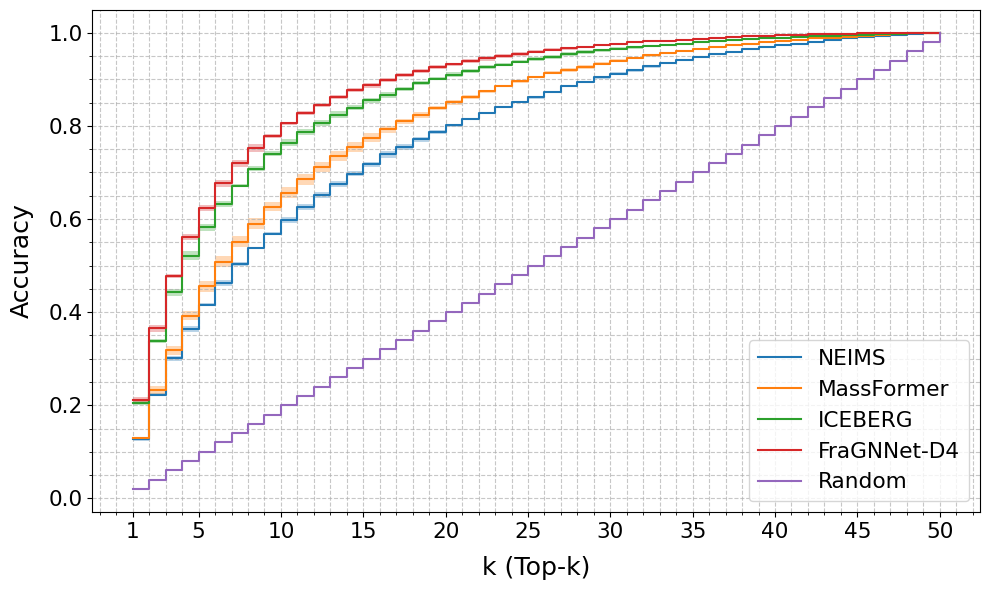

In [10]:
# Example data: x-axis (k values) and y-axis (top-k scores)
# k_values = [1, 5, 10, 20, 50]
# method1_scores = [0.70, 0.75, 0.80, 0.85, 0.90] #[0.9, 0.85, 0.8, 0.75, 0.7]
# method2_scores = [0.72, 0.78, 0.82, 0.87, 0.92] #[0.92, 0.87, 0.82, 0.78, 0.72]
# method3_scores = [0.68, 0.73, 0.78, 0.83, 0.88] #[0.88, 0.83, 0.78, 0.73, 0.68]
# all_method_scores = [method1_scores, method2_scores, method3_scores]
# all_method_labels = ['Method 1', 'Method 2', 'Method 3']

k_values = ks
k_means = [f"{k}_mean" for k in ks]
k_stds = [f"{k}_std" for k in ks]
all_method_means = [scaffold_topk_df[scaffold_topk_df["model"] == model][k_means].values[0] for model in models+["random"]]
all_method_stds = [scaffold_topk_df[scaffold_topk_df["model"] == model][k_stds].values[0] for model in models+["random"]]
all_method_labels = [model_to_label[model] for model in models] + ["Random"]

plot_top_k_accuracy(
    k_values=k_values,
    all_method_means=all_method_means,
    all_method_stds=all_method_stds,
    all_method_labels=all_method_labels,
    title=None, #"Scaffold Retrieval Top-k Accuracy",
    fontsize_scale=1.3,
    output_fp="../figs/ms2c_retrieval/scaffold_topk_accuracy.pdf"
)

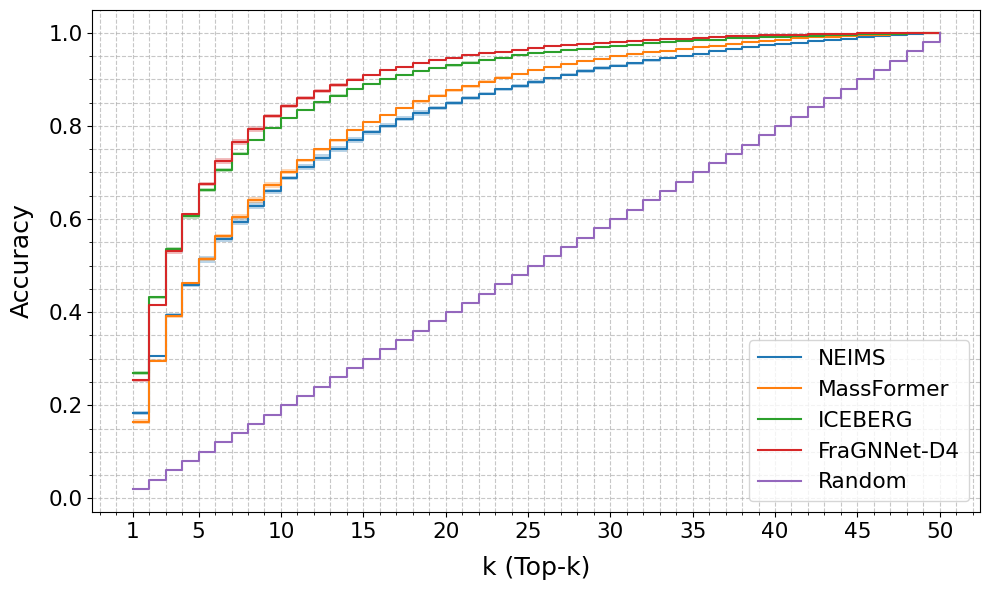

In [11]:
k_values = ks
k_means = [f"{k}_mean" for k in ks]
k_stds = [f"{k}_std" for k in ks]
all_method_means = [inchikey_topk_df[inchikey_topk_df["model"] == model][k_means].values[0] for model in models+["random"]]
all_method_stds = [inchikey_topk_df[inchikey_topk_df["model"] == model][k_stds].values[0] for model in models+["random"]]

plot_top_k_accuracy(
    k_values=k_values,
    all_method_means=all_method_means,
    all_method_stds=all_method_stds,
    all_method_labels=all_method_labels,
    title=None, #"InChIKey Retrieval Top-k Accuracy",
    fontsize_scale=1.3,
    output_fp="../figs/ms2c_retrieval/inchikey_topk_accuracy.pdf"
)

In [12]:
inchikey_summary_fp = os.path.join(inchikey_dp, "overall_stats_summary.csv")
scaffold_summary_fp = os.path.join(scaffold_dp, "overall_stats_summary.csv")

In [13]:
scaffold_summary_df = pd.read_csv(scaffold_summary_fp)
# remove seed info
scaffold_summary_df["model"] = scaffold_summary_df["model"].str[:-3]
# select correct ranking method
scaffold_summary_df = scaffold_summary_df[scaffold_summary_df["ranking method"] == scaffold_summary_df["model"].map(model_to_metric)].drop(columns=["ranking method"])
# average over seeds
scaffold_summary_df = scaffold_summary_df.groupby("model").mean().reset_index()
# remove unnecessary columns
scaffold_summary_df = scaffold_summary_df.drop(columns=["top-1", "top-3", "top-5", "top-10", "ans_score_mean", "ans_score_std"])
display(scaffold_summary_df)

,model,top-1 ratio,top-3 ratio,top-5 ratio,top-10 ratio,rank_mean,rank_std,rank_median,top_1_tanimoto_mean,top_1_tanimoto_std,ndcg_linear_mean,ndcg_linear_std,ndcg_exp_mean,ndcg_exp_std
0,fraggnn_d4_long,0.210655,0.477941,0.623346,0.805268,6.683927,7.640773,4.0,0.554747,0.273237,0.908545,0.057000,0.886494,0.069644
1,iceberg_inten3_100_long,0.204071,0.442203,0.581981,0.764382,7.624035,8.651527,4.0,0.549108,0.270746,0.904360,0.057573,0.881396,0.070222
2,massformer_long,0.128704,0.317869,0.455492,0.656869,10.104520,10.034872,6.4,0.475361,0.248759,0.886715,0.062120,0.859628,0.074350
3,neims_long,0.127387,0.300808,0.415983,0.597905,11.609847,11.200873,7.2,0.473826,0.248624,0.882423,0.063509,0.854406,0.076092


In [14]:
inchikey_summary_df = pd.read_csv(inchikey_summary_fp)
# remove seed info
inchikey_summary_df["model"] = inchikey_summary_df["model"].str[:-3]
# select correct ranking method
inchikey_summary_df = inchikey_summary_df[inchikey_summary_df["ranking method"] == inchikey_summary_df["model"].map(model_to_metric)].drop(columns=["ranking method"])
# average over seeds
inchikey_summary_df = inchikey_summary_df.groupby("model").mean().reset_index()
# remove unnecessary columns
inchikey_summary_df = inchikey_summary_df.drop(columns=["top-1", "top-3", "top-5", "top-10", "ans_score_mean", "ans_score_std"])
display(inchikey_summary_df)

,model,top-1 ratio,top-3 ratio,top-5 ratio,top-10 ratio,rank_mean,rank_std,rank_median,top_1_tanimoto_mean,top_1_tanimoto_std,ndcg_linear_mean,ndcg_linear_std,ndcg_exp_mean,ndcg_exp_std
0,fraggnn_d4_long,0.253895,0.530760,0.674781,0.842624,5.904381,7.120805,3.0,0.597122,0.274589,0.918766,0.053014,0.898905,0.065482
1,iceberg_inten3_100_long,0.269713,0.535638,0.662231,0.816718,6.392801,8.030049,3.0,0.607189,0.279243,0.917421,0.053851,0.897454,0.066532
2,massformer_long,0.164954,0.391333,0.514753,0.702060,9.018683,9.654221,5.0,0.517963,0.261565,0.898657,0.061502,0.874038,0.074176
3,neims_long,0.182951,0.394885,0.513142,0.687805,9.687734,10.703504,5.0,0.535189,0.266996,0.899847,0.062082,0.875490,0.075212


In [15]:
def plot_rank_histograms(
        k_values, 
        all_method_means,
        all_method_stds,
        all_method_labels,
        title="Distribution over Predicted Rank of the Correct Candidate",
        xlabel="Predicted Rank", 
        ylabel="Fraction of Queries",
        figsize=(10, 6), 
        alpha=0.5, 
        fontsize_scale=1.0, 
        output_fp=None):
    """
    Plot precomputed histograms (fractions per k) for multiple models as side-by-side bar charts.
    
    Parameters:
    - k_values: list or array
        Sorted list of rank values (e.g., [1, 2, 3, ..., k_max]).
    - all_method_histograms: list of lists
        Each sub-list contains the fraction of queries at each k for one model.
    - all_method_labels: list of str
        Labels corresponding to each model's histogram.
    - title: str
        The title of the plot.
    - xlabel: str
        Label for the x-axis.
    - ylabel: str
        Label for the y-axis.
    - figsize: tuple
        Figure size in inches.
    - alpha: float
        Transparency level for the bars.
    """

    # Ensure the lengths match
    if len(all_method_means) != len(all_method_labels):
        raise ValueError("Length of all_method_histograms and all_method_labels must match.")
    
    # Convert k_values to a numpy array for easy arithmetic
    k_values = np.array(k_values)
    n_models = len(all_method_means)
    
    # Determine bar width and offsets for side-by-side bars.
    total_width = 0.8  # total width reserved for all bars at one x location
    bar_width = total_width / n_models
    # Offsets to center the grouped bars at each k value
    offsets = np.linspace(-total_width/2 + bar_width/2, total_width/2 - bar_width/2, n_models)
    
    # Create a figure and an axes object
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot each model's histogram as a bar chart with an offset.
    for offset, mean, std, label in zip(offsets, all_method_means, all_method_stds, all_method_labels):
        ax.bar(
            k_values + offset, 
            mean, 
            width=bar_width, 
            alpha=alpha, 
            label=label, 
            edgecolor='black',
            yerr=std,
        )
    
    # Set the labels, title, and ticks on the axes
    ax.set_xlabel(xlabel, fontsize=14*fontsize_scale, labelpad=8*fontsize_scale)
    ax.set_ylabel(ylabel, fontsize=14*fontsize_scale, labelpad=8*fontsize_scale)
    # ax.set_title(title)
    ax.set_xticks(k_values)
    ax.tick_params(axis='both', which='major', labelsize=12*fontsize_scale)
    
    # Add legend
    ax.legend(fontsize=12*fontsize_scale)

    # Add gridlines
    ax.grid(axis="y", which='both', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    
    # Set title
    if title is not None:
        ax.set_title(title, fontsize=16*fontsize_scale)

    # Adjust layout to prevent clipping
    fig.tight_layout()
    
    # Save figure
    if output_fp is not None:
        plt.savefig(output_fp, format="pdf", bbox_inches="tight")

    # Show the plot
    plt.show()

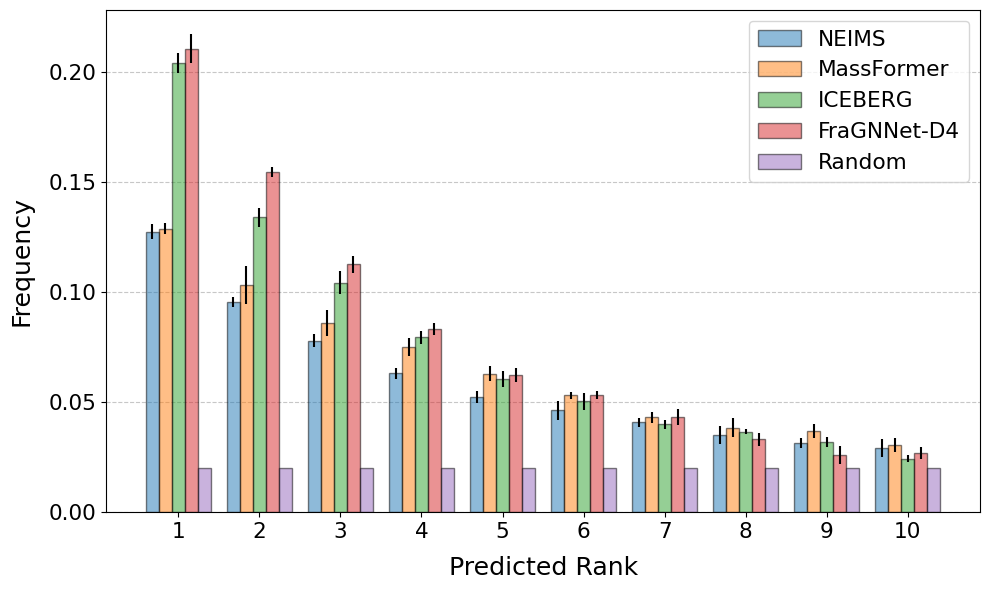

In [16]:
k_values = ks[:10]
k_means = [f"{k}_mean" for k in ks[:10]]
k_stds = [f"{k}_std" for k in ks[:10]]
all_method_means = [scaffold_rank_df[scaffold_rank_df["model"] == model][k_means].values[0] for model in models+["random"]]
all_method_stds = [scaffold_rank_df[scaffold_rank_df["model"] == model][k_stds].values[0] for model in models+["random"]]
all_method_labels = [model_to_label[model] for model in models] + ["Random"]

plot_rank_histograms(
    k_values=k_values,
    all_method_means=all_method_means,
    all_method_stds = all_method_stds,
    all_method_labels=all_method_labels,
    title=None, #"Scaffold Retrieval Rank Histogram",
    xlabel="Predicted Rank",
    ylabel="Frequency",
    figsize=(10, 6),
    alpha=0.5,
    fontsize_scale=1.3,
    output_fp="../figs/ms2c_retrieval/scaffold_ranks.pdf"
)

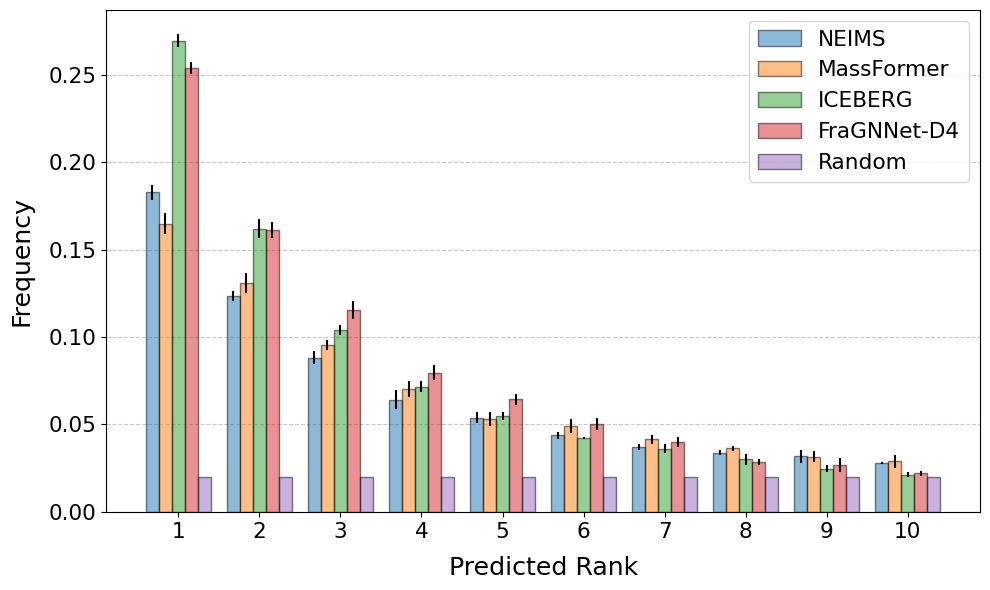

In [17]:
k_values = ks[:10]
k_means = [f"{k}_mean" for k in ks[:10]]
k_stds = [f"{k}_std" for k in ks[:10]]
all_method_means = [inchikey_rank_df[inchikey_rank_df["model"] == model][k_means].values[0] for model in models+["random"]]
all_method_stds = [inchikey_rank_df[inchikey_rank_df["model"] == model][k_stds].values[0] for model in models+["random"]]
all_method_labels = [model_to_label[model] for model in models] + ["Random"]

plot_rank_histograms(
    k_values=k_values[:10],
    all_method_means=all_method_means,
    all_method_stds=all_method_stds,
    all_method_labels=all_method_labels,
    title=None, #"InChIKey Retrieval Rank Histogram",
    xlabel="Predicted Rank",
    ylabel="Frequency",
    figsize=(10, 6),
    alpha=0.5,
    fontsize_scale=1.3,
    output_fp="../figs/ms2c_retrieval/inchikey_ranks.pdf"
)